<a href="https://colab.research.google.com/github/Shahidrrs/nutribone3/blob/main/nutribone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/nutribone', exist_ok=True)
print("Google Drive mounted and nutribone folder ready!")
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import random
import seaborn as sns

In [ ]:
import kagglehub

print("Downloading dataset 1 (mohamedgobara)...")
path1 = kagglehub.dataset_download("mohamedgobara/multi-class-knee-osteoporosis-x-ray-dataset")
print("Dataset 1 path:", path1)

print("\nDownloading dataset 2 (stevepython)...")
path2 = kagglehub.dataset_download("stevepython/osteoporosis-knee-xray-dataset")
print("Dataset 2 path:", path2)

100%|██████████| 1.17G/1.17G [00:10<00:00, 121MB/s]

Extracting files...


Dataset 1 path: /root/.cache/kagglehub/datasets/mohamedgobara/multi-class-knee-osteoporosis-x-ray-dataset/versions/1



100%|██████████| 280M/280M [00:02<00:00, 114MB/s]

Extracting files...


Dataset 2 path: /root/.cache/kagglehub/datasets/stevepython/osteoporosis-knee-xray-dataset/versions/2


In [ ]:
import random
import shutil
import os
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

random.seed(42)
np.random.seed(42)

if os.path.exists("/tmp/osteoporosis_merged"):
    shutil.rmtree("/tmp/osteoporosis_merged")
    print("Old merged folder deleted.")

merged_dir = "/tmp/osteoporosis_merged"
splits     = ['train', 'val', 'test']
classes    = ['Normal', 'Osteopenia', 'Osteoporosis']

targets = {
    'train': 724,
    'val':   144,
    'test':  98
}

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(merged_dir, split, cls), exist_ok=True)

def collect_images(src_dir):
    if not os.path.exists(src_dir):
        print(f"  WARNING: Not found: {src_dir}")
        return []
    return [
        os.path.join(src_dir, f)
        for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

def split_and_copy(image_paths, dst_class_dirs, label_prefix, train=0.75, val=0.15):
    random.shuffle(image_paths)
    n       = len(image_paths)
    n_train = int(n * train)
    n_val   = int(n * val)
    splits_map = {
        'train': image_paths[:n_train],
        'val':   image_paths[n_train:n_train + n_val],
        'test':  image_paths[n_train + n_val:]
    }
    counts = {}
    for split_name, paths in splits_map.items():
        dst = dst_class_dirs[split_name]
        for i, src in enumerate(paths):
            ext = os.path.splitext(src)[1].lower()
            shutil.copy2(src, os.path.join(dst, f"{label_prefix}_{i}{ext}"))
        counts[split_name] = len(paths)
    return counts

def augment_to_exact(src_dir, target_count, label_prefix='aug'):
    existing = [
        os.path.join(src_dir, f)
        for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    current = len(existing)
    if current > target_count:
        to_remove = random.sample(existing, current - target_count)
        for f in to_remove:
            os.remove(f)
        print(f"  Trimmed {current} → {target_count}")
        return
    if current < target_count:
        aug = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True,
            brightness_range=[0.8, 1.2],
            shear_range=0.1,
            fill_mode='nearest'
        )
        needed = target_count - current
        idx = 0
        print(f"  Augmenting {current} → {target_count} (need {needed})...")
        while idx < needed:
            src_img_path = random.choice(existing)
            try:
                img = load_img(src_img_path, target_size=(224, 224))
                x   = img_to_array(img).reshape((1, 224, 224, 3))
                for batch in aug.flow(x, batch_size=1):
                    Image.fromarray(batch[0].astype(np.uint8)).save(
                        os.path.join(src_dir, f"{label_prefix}_{idx}.jpg"))
                    idx += 1
                    break
            except Exception as e:
                continue
        print(f"  Done: {len(os.listdir(src_dir))} images")

d1_base    = os.path.join(path1, "OS Collected Data")
d1_sources = {
    'Normal':       os.path.join(d1_base, "Normal"),
    'Osteopenia':   os.path.join(d1_base, "Osteopenia"),
    'Osteoporosis': os.path.join(d1_base, "Osteoporosis"),
}
d2_sources = {
    'Normal':       os.path.join(path2, "normal", "normal"),
    'Osteoporosis': os.path.join(path2, "osteoporosis", "osteoporosis"),
}

for cls in classes:
    dst_dirs = {s: os.path.join(merged_dir, s, cls) for s in splits}
    imgs_d1  = collect_images(d1_sources.get(cls, ""))
    imgs_d2  = collect_images(d2_sources.get(cls, ""))
    counts1  = split_and_copy(imgs_d1, dst_dirs, label_prefix="d1")
    counts2  = split_and_copy(imgs_d2, dst_dirs, label_prefix="d2")
    print(f"\n{cls}: {len(imgs_d1)} D1 + {len(imgs_d2)} D2 = {len(imgs_d1)+len(imgs_d2)}")

print("\nBalancing classes...")
for cls in classes:
    for split_name in splits:
        target    = targets[split_name]
        split_dir = os.path.join(merged_dir, split_name, cls)
        augment_to_exact(split_dir, target, label_prefix=f'aug_{cls[:3].lower()}')

print("\nFinal summary:")
for split in splits:
    print(f"\n{split}/")
    for cls in classes:
        n = len(os.listdir(os.path.join(merged_dir, split, cls)))
        print(f"  {cls}: {n}")


Normal: 780 D1 + 186 D2 = 966

Osteopenia: 374 D1 + 0 D2 = 374

Osteoporosis: 793 D1 + 186 D2 = 979

Balancing classes...
  Augmenting 280 → 724 (need 444)...
  Done: 724 images
  Augmenting 56 → 144 (need 88)...
  Done: 144 images
  Augmenting 38 → 98 (need 60)...
  Done: 98 images
  Trimmed 733 → 724
  Trimmed 145 → 144
  Trimmed 101 → 98

Final summary:

train/
  Normal: 724
  Osteopenia: 724
  Osteoporosis: 724

val/
  Normal: 144
  Osteopenia: 144
  Osteoporosis: 144

test/
  Normal: 98
  Osteopenia: 98
  Osteoporosis: 98


In [ ]:
train_dir = os.path.join(merged_dir, 'train')
val_dir   = os.path.join(merged_dir, 'val')
test_dir  = os.path.join(merged_dir, 'test')

def make_generators(preprocess_fn, batch_size=16):
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.85, 1.15],
        fill_mode='nearest',
        preprocessing_function=preprocess_fn
    )
    val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=(224, 224), batch_size=batch_size,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=True
    )
    val_gen = val_datagen.flow_from_directory(
        val_dir, target_size=(224, 224), batch_size=batch_size,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=False
    )
    test_gen = test_datagen.flow_from_directory(
        test_dir, target_size=(224, 224), batch_size=1,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=False
    )
    return train_gen, val_gen, test_gen

def build_model(backbone, preprocess_fn_name):
    inputs     = layers.Input(shape=(224, 224, 3))
    backbone.trainable = False
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return models.Model(inputs, outputs)

print("Helper functions ready.")

Helper functions ready.


In [ ]:
print("=" * 50)
print("TRAINING MODEL 1: VGG-19")
print("=" * 50)

preprocess_vgg = tf.keras.applications.vgg19.preprocess_input
train_gen, val_gen, test_gen = make_generators(preprocess_vgg)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))

# Build VGG-19
vgg_base = tf.keras.applications.VGG19(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_vgg = build_model(vgg_base, 'vgg19')

# Stage 1
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_s1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("/content/drive/MyDrive/nutribone/vgg19_best.keras",
 monitor='val_accuracy', save_best_only=True, verbose=1)
]
print("\nVGG-19 Stage 1...")
h_vgg1 = model_vgg.fit(train_gen, validation_data=val_gen,
                        epochs=20, callbacks=cb_s1,
                        class_weight=class_weights)

# Stage 2 — unfreeze block4 + block5
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = 'block5' in layer.name or 'block4' in layer.name

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_s2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("vgg19_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nVGG-19 Stage 2...")
h_vgg2 = model_vgg.fit(train_gen, validation_data=val_gen,
                        epochs=40, callbacks=cb_s2,
                        class_weight=class_weights)

print(f"\nVGG-19 Best Val Accuracy: {max(h_vgg2.history['val_accuracy']):.4f}")

TRAINING MODEL 1: VGG-19
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

VGG-19 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.5522 - loss: 1.3759
Epoch 1: val_accuracy improved from None to 0.74074, saving model to vgg19_stage1.keras

Epoch 1: finished saving model to vgg19_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 118s 766ms/step - accuracy: 0.6031 - loss: 1.1781 - val_accuracy: 0.7407 - val_loss: 0.7192 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.6658 - loss: 0.9707
Epoch 2: val_accuracy did not improve from 0.74074
136/136 ━━━━━━━━━━━━━━━━━━━━ 83s 609ms/step - accuracy: 0.6644 - loss: 0.9367 - val_accuracy: 0.7361 - val_loss: 0.6608 - learning_rate: 0.0010
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.6796 - loss: 0.8614
Epoch 3: val_accuracy did not impro

In [ ]:
print("=" * 50)
print("TRAINING MODEL 2: ResNet50")
print("=" * 50)

preprocess_res = tf.keras.applications.resnet50.preprocess_input
train_gen_r, val_gen_r, test_gen_r = make_generators(preprocess_res)

res_base = tf.keras.applications.ResNet50(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_res = build_model(res_base, 'resnet50')

# Stage 1
model_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("/content/drive/MyDrive/nutribone/resnet50_best.keras",
 monitor='val_accuracy', save_best_only=True, verbose=1)
]
print("\nResNet50 Stage 1...")
h_res1 = model_res.fit(train_gen_r, validation_data=val_gen_r,
                        epochs=20, callbacks=cb_r1,
                        class_weight=class_weights)

# Stage 2 — unfreeze last 40 layers
res_base.trainable = True
for layer in res_base.layers[:-40]:
    layer.trainable = False

model_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("resnet50_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50 Stage 2...")
h_res2 = model_res.fit(train_gen_r, validation_data=val_gen_r,
                        epochs=40, callbacks=cb_r2,
                        class_weight=class_weights)

print(f"\nResNet50 Best Val Accuracy: {max(h_res2.history['val_accuracy']):.4f}")

TRAINING MODEL 2: ResNet50
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

ResNet50 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.6211 - loss: 1.1811
Epoch 1: val_accuracy improved from None to 0.75000, saving model to resnet50_stage1.keras

Epoch 1: finished saving model to resnet50_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 110s 690ms/step - accuracy: 0.6570 - loss: 1.0512 - val_accuracy: 0.7500 - val_loss: 0.7128 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.7016 - loss: 0.8986
Epoch 2: val_accuracy improved from 0.75000 to 0.77778, saving model to resnet50_stage1.keras

Epoch 2: finished saving model to resnet50_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 83s 611ms/step - accuracy: 0.7012 - loss: 0.8810 - val_accuracy: 0.7778 - val_loss: 0.6581 - learning_rate: 0.0010
Epoch 3/20
13

In [ ]:
print("=" * 50)
print("TRAINING MODEL 3: EfficientNetB0")
print("=" * 50)

preprocess_eff = tf.keras.applications.efficientnet.preprocess_input
train_gen_e, val_gen_e, test_gen_e = make_generators(preprocess_eff)

eff_base = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_eff = build_model(eff_base, 'efficientnet')

# Stage 1
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_e1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("effnet_stage1.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nEfficientNetB0 Stage 1...")
h_eff1 = model_eff.fit(train_gen_e, validation_data=val_gen_e,
                        epochs=20, callbacks=cb_e1,
                        class_weight=class_weights)

# Stage 2 — unfreeze top 30%
eff_base.trainable = True
freeze_until = int(len(eff_base.layers) * 0.7)
for layer in eff_base.layers[:freeze_until]:
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_e2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("/content/drive/MyDrive/nutribone/effnet_best.keras",
 monitor='val_accuracy', save_best_only=True, verbose=1)
]
print("\nEfficientNetB0 Stage 2...")
h_eff2 = model_eff.fit(train_gen_e, validation_data=val_gen_e,
                        epochs=40, callbacks=cb_e2,
                        class_weight=class_weights)

print(f"\nEfficientNetB0 Best Val Accuracy: {max(h_eff2.history['val_accuracy']):.4f}")

TRAINING MODEL 3: EfficientNetB0
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

EfficientNetB0 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.5857 - loss: 1.2921
Epoch 1: val_accuracy improved from None to 0.70602, saving model to effnet_stage1.keras

Epoch 1: finished saving model to effnet_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 133s 752ms/step - accuracy: 0.6524 - loss: 1.0926 - val_accuracy: 0.7060 - val_loss: 0.7688 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.6782 - loss: 0.8774
Epoch 2: val_accuracy improved from 0.70602 to 0.74537, saving model to effnet_stage1.keras

Epoch 2: finished saving model to effnet_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 79s 580ms/step - accuracy: 0.6915 - loss: 0.8729 - val_accuracy: 0.7454 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 3/2

In [ ]:
print("=" * 50)
print("TRAINING MODEL 4: ResNet50V2")
print("=" * 50)

preprocess_res2 = tf.keras.applications.resnet_v2.preprocess_input
train_gen_r2, val_gen_r2, test_gen_r2 = make_generators(preprocess_res2)

res_base_v2 = tf.keras.applications.ResNet50V2(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_res2 = build_model(res_base_v2, 'resnet50v2')

# Stage 1
model_res2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r2s1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("/content/drive/MyDrive/nutribone/resnet50v2_best.keras",
 monitor='val_accuracy', save_best_only=True, verbose=1)
]
print("\nResNet50V2 Stage 1...")
h_res2s1 = model_res2.fit(train_gen_r2, validation_data=val_gen_r2,
                           epochs=20, callbacks=cb_r2s1,
                           class_weight=class_weights)

# Stage 2 — unfreeze last 40 layers
res_base_v2.trainable = True
for layer in res_base_v2.layers[:-40]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in res_base_v2.layers if l.trainable)}")

model_res2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r2s2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("resnet50v2_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50V2 Stage 2...")
h_res2s2 = model_res2.fit(train_gen_r2, validation_data=val_gen_r2,
                           epochs=40, callbacks=cb_r2s2,
                           class_weight=class_weights)

print(f"\nResNet50V2 Best Val Accuracy: {max(h_res2s2.history['val_accuracy']):.4f}")

TRAINING MODEL 4: ResNet50V2
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

ResNet50V2 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.5839 - loss: 1.3098
Epoch 1: val_accuracy improved from None to 0.71065, saving model to resnet50v2_stage1.keras

Epoch 1: finished saving model to resnet50v2_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 101s 639ms/step - accuracy: 0.6363 - loss: 1.1301 - val_accuracy: 0.7106 - val_loss: 0.7536 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.6545 - loss: 0.9580
Epoch 2: val_accuracy improved from 0.71065 to 0.75694, saving model to resnet50v2_stage1.keras

Epoch 2: finished saving model to resnet50v2_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 76s 558ms/step - accuracy: 0.6671 - loss: 0.9223 - val_accuracy: 0.7569 - val_loss: 0.6730 - learning_rate: 0.0010
E

In [ ]:
print("Loading all 4 best models...")
m_vgg  = tf.keras.models.load_model("vgg19_best.keras")
m_res  = tf.keras.models.load_model("resnet50_best.keras")
m_eff  = tf.keras.models.load_model("effnet_best.keras")
m_res2 = tf.keras.models.load_model("resnet50v2_best.keras")

class_names = ['Normal', 'Osteopenia', 'Osteoporosis']

def get_preds(model, preprocess_fn, n_tta=20):
    """Get TTA predictions from a model."""
    tta_datagen = ImageDataGenerator(
        rotation_range=5,
        horizontal_flip=True,
        zoom_range=0.03,
        preprocessing_function=preprocess_fn
    )
    # Get total test samples
    total = sum(
        len(os.listdir(os.path.join(test_dir, cls)))
        for cls in ['Normal', 'Osteopenia', 'Osteoporosis']
    )
    preds = np.zeros((total, 3))

    for i in range(n_tta):
        gen = tta_datagen.flow_from_directory(
            test_dir, target_size=(224, 224), batch_size=1,
            classes=['Normal', 'Osteopenia', 'Osteoporosis'],
            class_mode='categorical', shuffle=False)
        gen.reset()
        preds += model.predict(gen, steps=len(gen), verbose=0)
        print(f"  TTA round {i+1}/{n_tta} done")
    return preds / n_tta

# VGG-19 and ResNet50 are strongest — give them 30 TTA rounds
print("\nVGG-19 predictions (30 TTA rounds)...")
preds_vgg = get_preds(m_vgg,
                      tf.keras.applications.vgg19.preprocess_input,
                      n_tta=30)

print("\nResNet50 predictions (30 TTA rounds)...")
preds_res = get_preds(m_res,
                      tf.keras.applications.resnet50.preprocess_input,
                      n_tta=30)

# EfficientNetB0 and ResNet50V2 get 20 TTA rounds
print("\nEfficientNetB0 predictions (20 TTA rounds)...")
preds_eff = get_preds(m_eff,
                      tf.keras.applications.efficientnet.preprocess_input,
                      n_tta=20)

print("\nResNet50V2 predictions (20 TTA rounds)...")
preds_res2 = get_preds(m_res2,
                       tf.keras.applications.resnet_v2.preprocess_input,
                       n_tta=20)

# Get true labels
label_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input
).flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=1,
    classes=['Normal', 'Osteopenia', 'Osteoporosis'],
    class_mode='categorical', shuffle=False)
y_true = label_gen.classes

print("\nAll predictions done!")

Loading all 4 best models...

VGG-19 predictions (30 TTA rounds)...
Found 294 images belonging to 3 classes.
  TTA round 1/30 done
Found 294 images belonging to 3 classes.
  TTA round 2/30 done
Found 294 images belonging to 3 classes.
  TTA round 3/30 done
Found 294 images belonging to 3 classes.
  TTA round 4/30 done
Found 294 images belonging to 3 classes.
  TTA round 5/30 done
Found 294 images belonging to 3 classes.
  TTA round 6/30 done
Found 294 images belonging to 3 classes.
  TTA round 7/30 done
Found 294 images belonging to 3 classes.
  TTA round 8/30 done
Found 294 images belonging to 3 classes.
  TTA round 9/30 done
Found 294 images belonging to 3 classes.
  TTA round 10/30 done
Found 294 images belonging to 3 classes.
  TTA round 11/30 done
Found 294 images belonging to 3 classes.
  TTA round 12/30 done
Found 294 images belonging to 3 classes.
  TTA round 13/30 done
Found 294 images belonging to 3 classes.
  TTA round 14/30 done
Found 294 images belonging to 3 classes.
  TT


Searching for optimal ensemble weights...
(This may take ~1 minute)

Best weights found:
  VGG-19:        0.2
  ResNet50:      1.0
  EfficientNetB0:0.2
  ResNet50V2:    0.2

Best Ensemble Accuracy: 87.07%
Optimal ensemble weights saved to 'best_ensemble_weights.json'. Commit this file to GitHub!

--- Final Ensemble Classification Report ---
              precision    recall  f1-score   support

      Normal       0.94      0.87      0.90        98
  Osteopenia       0.92      0.83      0.87        98
Osteoporosis       0.78      0.92      0.84        98

    accuracy                           0.87       294
   macro avg       0.88      0.87      0.87       294
weighted avg       0.88      0.87      0.87       294



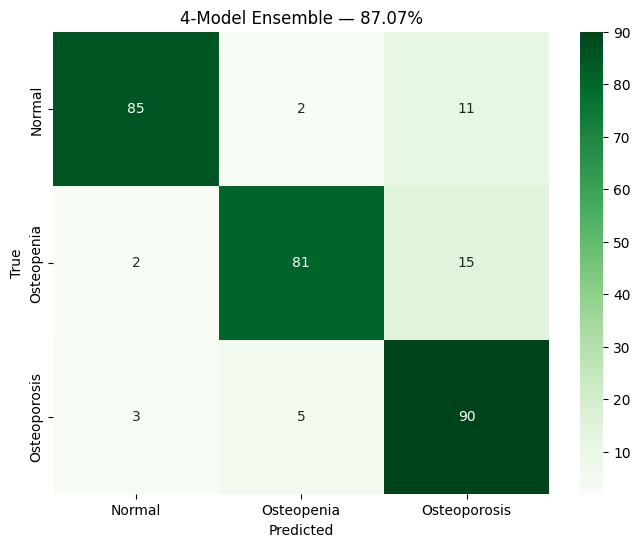

In [ ]:
import json

# Define the file path where ensemble weights will be stored in your repo
WEIGHTS_FILE = "best_ensemble_weights.json"

if os.path.exists(WEIGHTS_FILE):
    print(f"\nFound pre-calculated ensemble weights in '{WEIGHTS_FILE}'. Loading weights...")
    with open(WEIGHTS_FILE, 'r') as f:
        saved_data = json.load(f)

    # Extract weights and reconstruct the optimal ensemble array directly
    best_w = saved_data["weights"]
    best_acc = saved_data["accuracy"]

    w1, w2, w3, w4 = best_w
    best_preds = (w1 * preds_vgg + w2 * preds_res + w3 * preds_eff + w4 * preds_res2)

    print(f"Loaded Weights -> VGG-19: {w1:.1f}, ResNet50: {w2:.1f}, EfficientNetB0: {w3:.1f}, ResNet50V2: {w4:.1f}")
    print(f"Expected Ensemble Accuracy: {best_acc * 100:.2f}%")

else:
    print("\nSearching for optimal ensemble weights...")
    print("(This may take ~1 minute)")

    best_acc   = 0
    best_w     = (1, 1, 1, 1)
    best_preds = None

    # Search weight combinations for all 4 models
    for w1 in np.arange(0.2, 1.3, 0.2):      # VGG-19
        for w2 in np.arange(0.2, 1.3, 0.2):   # ResNet50
            for w3 in np.arange(0.2, 1.1, 0.2): # EfficientNetB0
                for w4 in np.arange(0.2, 1.3, 0.2): # ResNet50V2
                    ensemble = (w1*preds_vgg + w2*preds_res +
                                w3*preds_eff + w4*preds_res2)
                    y_pred   = np.argmax(ensemble, axis=1)
                    acc      = np.sum(y_pred == y_true) / len(y_true)
                    if acc > best_acc:
                        best_acc   = acc
                        best_w     = (w1, w2, w3, w4)
                        best_preds = ensemble.copy()

    print(f"\nBest weights found:")
    print(f"  VGG-19:        {best_w[0]:.1f}")
    print(f"  ResNet50:      {best_w[1]:.1f}")
    print(f"  EfficientNetB0:{best_w[2]:.1f}")
    print(f"  ResNet50V2:    {best_w[3]:.1f}")
    print(f"\nBest Ensemble Accuracy: {best_acc * 100:.2f}%")

    # Save the found weights to a JSON file so you can commit it to GitHub
    output_data = {
        "weights": [float(best_w[0]), float(best_w[1]), float(best_w[2]), float(best_w[3])],
        "accuracy": float(best_acc)
    }
    with open(WEIGHTS_FILE, 'w') as f:
        json.dump(output_data, f, indent=4)
    print(f"Optimal ensemble weights saved to '{WEIGHTS_FILE}'. Commit this file to GitHub!")

# ── Metrics and Visualization Execution (Runs instantly in both cases) ──
y_pred_final = np.argmax(best_preds, axis=1)

print("\n--- Final Ensemble Classification Report ---")
print(classification_report(y_true, y_pred_final, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'4-Model Ensemble — {best_acc*100:.2f}%')
plt.show()

import shutil
shutil.copy2('best_ensemble_weights.json',
 '/content/drive/MyDrive/nutribone/best_ensemble_weights.json')
print("All files saved to Google Drive!")


In [ ]:
import kagglehub

print("Downloading Sachinkumar dataset...")
path_sach = kagglehub.dataset_download("sachinkumar413/osteoporosis-knee-dataset-preprocessed128x256")
print("Sachinkumar path:", path_sach)

100%|██████████| 1.94M/1.94M [00:00<00:00, 139MB/s]

Extracting files...
Sachinkumar path: /root/.cache/kagglehub/datasets/sachinkumar413/osteoporosis-knee-dataset-preprocessed128x256/versions/1


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Enforce global 3-class mapping to align with your trained model's structure
GLOBAL_CLASSES = ['Normal', 'Osteopenia', 'Osteoporosis']

def ensemble_predict_from_folder(folder, preprocess_vgg, preprocess_res, preprocess_eff, n_tta=10):
    # Count images existing within the global target directories
    total = 0
    for c in GLOBAL_CLASSES:
        class_path = os.path.join(folder, c)
        if os.path.isdir(class_path):
            total += len(os.listdir(class_path))

    preds_vgg = np.zeros((total, 3))
    preds_res = np.zeros((total, 3))
    preds_eff = np.zeros((total, 3))

    tta_datagen_vgg = ImageDataGenerator(rotation_range=5, horizontal_flip=True, zoom_range=0.03, preprocessing_function=preprocess_vgg)
    tta_datagen_res = ImageDataGenerator(rotation_range=5, horizontal_flip=True, zoom_range=0.03, preprocessing_function=preprocess_res)
    tta_datagen_eff = ImageDataGenerator(rotation_range=5, horizontal_flip=True, zoom_range=0.03, preprocessing_function=preprocess_eff)

    for i in range(n_tta):
        for datagen, preds, model in [
            (tta_datagen_vgg, preds_vgg, m_vgg),
            (tta_datagen_res, preds_res, m_res),
            (tta_datagen_eff, preds_eff, m_eff)
        ]:
            # Explicitly providing classes=GLOBAL_CLASSES stops the generator from shifting indices
            # if 'Osteopenia' is missing from the directory
            gen = datagen.flow_from_directory(
                folder,
                target_size=(224, 224),
                batch_size=1,
                classes=GLOBAL_CLASSES,
                class_mode='categorical',
                shuffle=False)
            gen.reset()
            preds += model.predict(gen, steps=len(gen), verbose=0)
        print(f" TTA round {i+1}/{n_tta} done")

    preds_vgg /= n_tta
    preds_res /= n_tta
    preds_eff /= n_tta

    ensemble = (preds_vgg + preds_res + preds_eff) / 3

    label_gen = ImageDataGenerator(preprocessing_function=preprocess_vgg).flow_from_directory(
        folder, target_size=(224, 224), batch_size=1, classes=GLOBAL_CLASSES, class_mode='categorical', shuffle=False)

    y_true = label_gen.classes
    return ensemble, y_true

# ── Test on Sachinkumar dataset (2 classes only) ──
print("\nTesting on Sachinkumar dataset (Normal vs Osteoporosis)...")
sach_dir = os.path.join(path_sach, "Osteoporosis Knee Dataset")

# Obtain 3-class predictions even though the input folder only has 2 classes
ensemble_sach, y_true_sach = ensemble_predict_from_folder(
    sach_dir,
    tf.keras.applications.vgg19.preprocess_input,
    tf.keras.applications.resnet50.preprocess_input,
    tf.keras.applications.efficientnet.preprocess_input,
    n_tta=10
)

# Fix Ground Truth: Map true Osteoporosis labels (structural index 2) down to index 1
y_true_sach_2class = np.where(y_true_sach == 2, 1, y_true_sach)

# Collapse Predictions: Map 3 model outputs down to a 2-class layout
sach_ensemble_2class = np.zeros((len(y_true_sach), 2))
sach_ensemble_2class[:, 0] = ensemble_sach[:, 0]                       # Index 0: Normal
sach_ensemble_2class[:, 1] = ensemble_sach[:, 1] + ensemble_sach[:, 2] # Index 1: Osteopenia + Osteoporosis

# Evaluate binary performance metrics
sach_classes = ['Normal', 'Osteoporosis']
y_pred_sach = np.argmax(sach_ensemble_2class, axis=1)
acc_sach = np.sum(y_pred_sach == y_true_sach_2class) / len(y_true_sach_2class)

print(f"\n{'='*50}")
print(f"Dataset: Sachinkumar (2-class)")
print(f"Total images: {len(y_true_sach_2class)}")
print(f"Accuracy: {acc_sach*100:.2f}%")
print(f"{'='*50}")

print(classification_report(y_true_sach_2class, y_pred_sach, target_names=sach_classes))

# Plot performance mapping matrix
cm_sach = confusion_matrix(y_true_sach_2class, y_pred_sach)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sach, annot=True, fmt='d', xticklabels=sach_classes, yticklabels=sach_classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Sachinkumar Dataset — {acc_sach*100:.2f}%')
plt.show()



Testing on Sachinkumar dataset (Normal vs Osteoporosis)...


NameError: name 'path_sach' is not defined